<a href="https://colab.research.google.com/github/Elnathan9414/machine_learning/blob/main/Assigment_3_Josue_Elnathan_Mbondo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Course: DA3B – Machine Learning
## Student Name : ***Josue Elnathan Mbondo***
## Instructor Name: ***Mohammed Ghori***

# Section 1. Problem Recap and Dataset Overview

## ML Objective

The objective of this project is to predict **loan default risk** using borrower and loan information. The target variable is **`loan_status`**, where `0` represents a non-default loan and `1` represents a default loan.

## Learning Style

This project uses **supervised learning** because the dataset contains a known target variable, `loan_status`. The model learns from historical data and uses the learned patterns to predict loan status for new observations.

## Algorithm Family

This is a **binary classification** problem because the target variable has two possible outcomes: default and non-default. **Logistic Regression** will be used as the baseline model, while **Random Forest** will be used as the primary model.

## Evaluation Strategy

The models will be evaluated using **Accuracy, Precision, Recall, F1-score, and ROC-AUC**. Particular attention will be given to **Recall, F1-score, and ROC-AUC**, since correctly identifying potential loan defaults is important.

## Dataset Overview

The cleaned dataset produced in Assignment 2 was saved on **GitHub** and will be loaded directly into this notebook. The dataset was originally obtained from Kaggle and processed during Assignment 2. The final cleaned version is now used for the machine learning model development and evaluation.

## Import Librairies

In [74]:
!pip install kagglehub

In [75]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os
import math
import numpy as np
from kagglehub import KaggleDatasetAdapter
from google.colab import drive
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV

### Dataset Preparation and Storage

In the previous exercise, the **Credit Risk Dataset** was imported from Kaggle and processed through data cleaning and preparation steps. Missing values were handled, data quality was improved, and the final dataset was prepared for machine learning.

After completing the data preparation, the **final cleaned dataset was saved on GitHub**. In this exercise, the dataset is loaded directly from GitHub and will be used to build, train, and evaluate the machine learning models.

In [81]:
# Load the final cleaned dataset from GitHub
url = "https://raw.githubusercontent.com/Elnathan9414/machine_learning/main/credit_risk_final.csv"

df = pd.read_csv(url)

# Display basic information
print("Dataset shape:", df.shape)
print("\nDataset information:")
df.info()

print("\nTarget variable distribution:")
print(df["loan_status"].value_counts())

df.head()

Dataset shape: (32385, 25)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32385 entries, 0 to 32384
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32385 non-null  int64  
 1   person_income                32385 non-null  int64  
 2   person_emp_length            32385 non-null  float64
 3   loan_amnt                    32385 non-null  int64  
 4   loan_int_rate                32385 non-null  float64
 5   loan_status                  32385 non-null  int64  
 6   loan_percent_income          32385 non-null  float64
 7   cb_person_cred_hist_length   32385 non-null  int64  
 8   high_loan_burden             32385 non-null  int64  
 9   person_income_log            32385 non-null  float64
 10  person_home_ownership_OTHER  32385 non-null  bool   
 11  person_home_ownership_OWN    32385 non-null  bool   
 12  person_home_ownership_REN

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,high_loan_burden,person_income_log,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,12.0,24000,16.02,1,0.38,3,1,10.985310,...,False,True,False,False,False,True,False,False,False,True
1,22,22880,5.0,2000,11.14,0,0.10,2,0,10.038062,...,False,False,False,True,False,False,False,False,False,False
2,25,22880,1.0,5500,12.87,1,0.38,3,1,10.038062,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,24000,15.23,1,0.38,2,1,11.089821,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,24000,14.27,1,0.38,4,1,10.904138,...,True,False,False,False,True,False,False,False,False,True


## 2. Train/Test Strategy and Baseline

The dataset will be divided into three subsets: **training, validation, and testing**.

A stratified split will be used to preserve the proportion of default and non-default cases in each subset. The data will first be divided into **70% training data and 30% temporary data**. The temporary data will then be divided equally into **15% validation data and 15% test data**.

The **training set** will be used to train the model, the **validation set** will be used to assess model performance during development, and the **test set** will be kept separate for the final evaluation.

**Logistic Regression** will be used as the baseline model. It is an appropriate starting point because it is a simple, interpretable classification algorithm that is well suited to binary classification.

Model success will be evaluated using **Accuracy, Precision, Recall, F1-score, and ROC-AUC**. Because the objective is to identify potential loan defaults, **Recall and F1-score** will be particularly important. A good model should identify as many actual defaults as possible while maintaining a reasonable level of precision.

## Section 2. Train/Test Strategy and Baseline

The dataset will be divided into three subsets using a stratified 60/20/20 split:

- **60% Training set** – used to train the machine learning models.
- **20% Validation set** – used to compare and improve models during development.
- **20% Test set** – kept separate for the final evaluation.

Stratification will be used to maintain a similar proportion of default and non-default cases across the three subsets.

A **DummyClassifier** will be used as the baseline model. This provides a simple reference point that allows the performance of the machine learning models to be compared against a naive prediction strategy.

Model success will be assessed mainly using **F1-score and ROC-AUC**, together with Precision, Recall, and Accuracy. Since identifying loan defaults is important, Recall and F1-score will receive particular attention.

#### 2.1 Split train and test features

In [82]:
# Separate features and target
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (32385, 24)
Target shape: (32385,)


#### 2.2 Train and temporary data (60%)

In [83]:
# First split: 60% training and 40% temporary data

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Temporary set:", X_temp.shape)

Training set: (19431, 24)
Temporary set: (12954, 24)


#### 2.3 Validation and test set

In [85]:
# Second split: 20% validation and 20% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (19431, 24)
Validation set: (6477, 24)
Test set: (6477, 24)


In [86]:
# Display the size and proportion of each dataset

total = len(df)

print(f"Training   : {len(X_train)} rows ({len(X_train)/total:.1%})")
print(f"Validation : {len(X_val)} rows ({len(X_val)/total:.1%})")
print(f"Test       : {len(X_test)} rows ({len(X_test)/total:.1%})")

Training   : 19431 rows (60.0%)
Validation : 6477 rows (20.0%)
Test       : 6477 rows (20.0%)


### 2.4 DummyClassifier Baseline

In [87]:
# Create the baseline model
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

# Train the baseline model
dummy_model.fit(X_train, y_train)

print("DummyClassifier baseline trained successfully.")

DummyClassifier baseline trained successfully.


In [88]:
# Generate predictions on the validation set

y_val_dummy = dummy_model.predict(X_val)
y_val_dummy_proba = dummy_model.predict_proba(X_val)[:, 1]

print("Predictions generated successfully.")
print("First 10 predictions:", y_val_dummy[:10])

Predictions generated successfully.
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


The first 10 predictions generated by the **DummyClassifier** are all `0`, which means the model predicts **non-default** for every observation.

This behavior is expected because the baseline uses the **`most_frequent`** strategy and always predicts the majority class found in the training dataset. As a result, the model does not learn any patterns from the input features and is unable to identify potential default cases.

These predictions confirm that the DummyClassifier serves only as a **baseline reference model** and that more advanced models are needed to capture the relationship between borrower characteristics and loan default risk.

In [89]:
dummy_accuracy = accuracy_score(y_val, y_val_dummy)
dummy_precision = precision_score(y_val, y_val_dummy, zero_division=0)
dummy_recall = recall_score(y_val, y_val_dummy, zero_division=0)
dummy_f1 = f1_score(y_val, y_val_dummy, zero_division=0)
dummy_roc_auc = roc_auc_score(y_val, y_val_dummy_proba)

print("DummyClassifier Baseline Performance")
print("------------------------------------")
print(f"Accuracy : {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall   : {dummy_recall:.4f}")
print(f"F1-score : {dummy_f1:.4f}")
print(f"ROC-AUC  : {dummy_roc_auc:.4f}")

DummyClassifier Baseline Performance
------------------------------------
Accuracy : 0.7812
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.5000


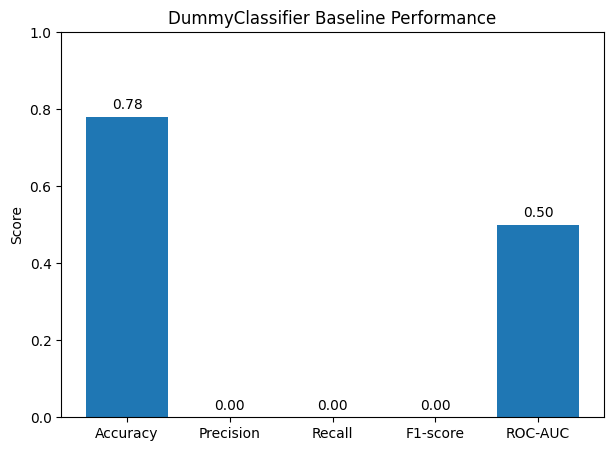

In [90]:

# Baseline metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
scores = [
    dummy_accuracy,
    dummy_precision,
    dummy_recall,
    dummy_f1,
    dummy_roc_auc
]

# Create bar chart
plt.figure(figsize=(7,5))
plt.bar(metrics, scores)

plt.title("DummyClassifier Baseline Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

# Display values on bars
for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha="center")

plt.show()

The baseline model provides a useful starting point for evaluating the performance of future machine learning models. Although the **DummyClassifier** achieved an **accuracy of 78.12%**, this result is misleading because it always predicts the majority class (non-default).

The chart shows that **Precision, Recall, and F1-score are all 0.00**, meaning the model failed to identify any loan default cases. In addition, the **ROC-AUC score of 0.50** indicates that the model has no real ability to distinguish between default and non-default loans.

These results demonstrate that **accuracy alone is not a sufficient evaluation metric** for this classification problem. The baseline establishes a reference point, and the next models (Logistic Regression and Random Forest) should achieve higher Recall, F1-score, and ROC-AUC values while maintaining good overall performance.

For this loan default prediction problem, success is not measured by accuracy alone. The model should correctly identify borrowers who are likely to default while minimizing incorrect predictions.

The following evaluation metrics will be used:

- **Recall**: Measures how many actual loan defaults are correctly identified. This is the most important metric because missing a default case could increase financial risk.
- **F1-score**: Balances precision and recall, making it useful when the classes are imbalanced.
- **ROC-AUC**: Measures the model's ability to distinguish between default and non-default loans across different classification thresholds.
- **Accuracy**: Provides the overall percentage of correct predictions but will not be used as the only measure of success because the dataset contains more non-default cases than default cases.
- **Precision**: Measures how many predicted defaults are actually defaults, helping reduce false positive predictions.

A successful model should achieve a **higher Recall, F1-score, and ROC-AUC than the baseline DummyClassifier**, while maintaining a good overall level of accuracy and precision.

## Section 3. Model Implementation

In this section, machine learning models are implemented using the training dataset created in the previous step.

Two classification models will be developed and evaluated:

- **Logistic Regression**: A simple and interpretable baseline classification model.
- **Random Forest**: The primary machine learning model selected for this project because it can capture complex relationships between borrower characteristics and loan default risk.

Both models will be trained on the training set and evaluated on the validation set before the final evaluation on the test set.

### 3.1 Data preprocessing

In [91]:
# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.




Before training the Logistic Regression model, numerical features are standardized using **StandardScaler**, while categorical variables are converted into numerical representations using **One-Hot Encoding**. Missing values are handled using median imputation for numerical features and most frequent imputation for categorical features.

### 3.2 Train logistic regression

In [92]:
# Create Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 3.3 Predictions

In [93]:
# Predict on validation data
y_val_log = logistic_model.predict(X_val)
y_val_log_proba = logistic_model.predict_proba(X_val)[:, 1]

print("First 10 predictions:")
print(y_val_log[:10])

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


### 3.4 Evaluations metrics

In [95]:

# Calculate metrics
log_accuracy = accuracy_score(y_val, y_val_log)
log_precision = precision_score(y_val, y_val_log)
log_recall = recall_score(y_val, y_val_log)
log_f1 = f1_score(y_val, y_val_log)
log_auc = roc_auc_score(y_val, y_val_log_proba)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1-score : {log_f1:.4f}")
print(f"ROC-AUC  : {log_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.8282
Precision: 0.6759
Recall   : 0.4121
F1-score : 0.5121
ROC-AUC  : 0.8307


The Logistic Regression model performed significantly better than the DummyClassifier baseline. While the baseline predicted only the majority class and failed to identify any loan defaults, Logistic Regression was able to detect a substantial number of default cases.

The model achieved an **Accuracy of 82.82%**, which is higher than the baseline accuracy of 78.12%. More importantly, it achieved a **Recall of 41.21%**, meaning it correctly identified over 40% of the actual loan defaults. The **F1-score of 51.21%** shows a better balance between precision and recall, while the **ROC-AUC score of 0.8307** indicates a strong ability to distinguish between default and non-default loans.

These results show that Logistic Regression provides a meaningful improvement over the baseline model and serves as a strong benchmark before implementing the Random Forest model.

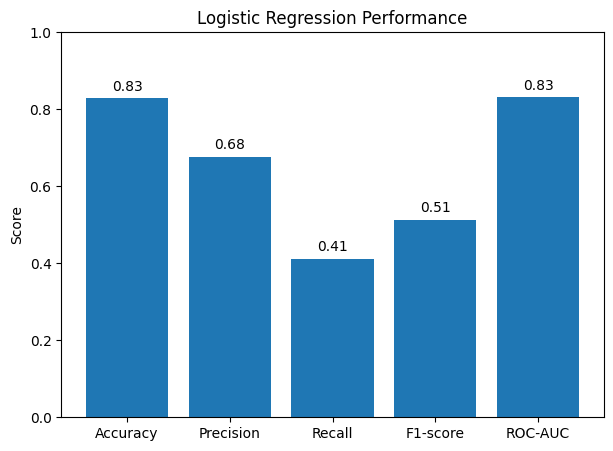

In [96]:

# Logistic Regression metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
scores = [
    log_accuracy,
    log_precision,
    log_recall,
    log_f1,
    log_auc
]

plt.figure(figsize=(7,5))
plt.bar(metrics, scores)

plt.title("Logistic Regression Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

# Display values on bars
for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha="center")

plt.show()

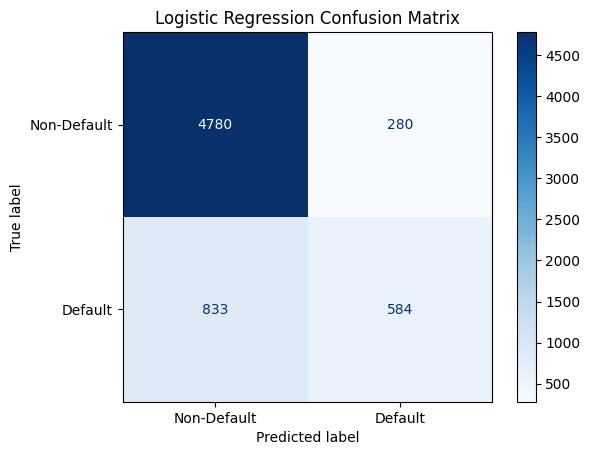

In [97]:
cm = confusion_matrix(y_val, y_val_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

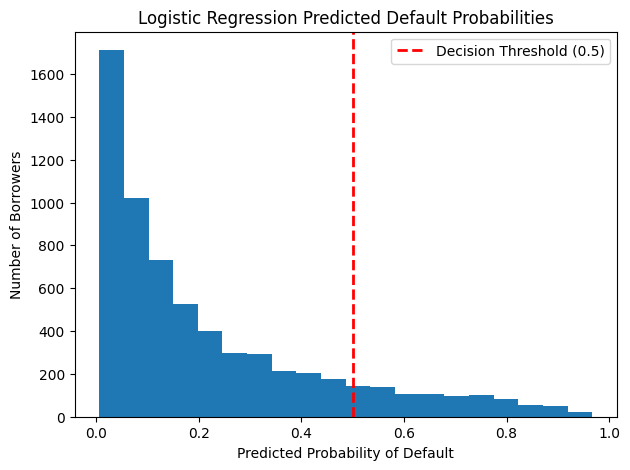

In [98]:
plt.figure(figsize=(7,5))
plt.hist(y_val_log_proba, bins=20)

# Decision threshold
plt.axvline(x=0.5, color="red", linestyle="--", linewidth=2, label="Decision Threshold (0.5)")

plt.title("Logistic Regression Predicted Default Probabilities")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Borrowers")
plt.legend()

plt.show()

### 3.5 Random Forest Model

Random Forest is selected as the primary model for this project because it is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture non-linear relationships and interactions between borrower characteristics and loan default risk. The model will be trained using the training dataset and evaluated on the validation dataset.

#### Import and train model

In [99]:

# Create Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


#### Prediction

In [100]:
# Predictions on validation set
y_val_rf = rf_model.predict(X_val)
y_val_rf_proba = rf_model.predict_proba(X_val)[:, 1]

print("First 10 Random Forest predictions:")
print(y_val_rf[:10])

First 10 Random Forest predictions:
[0 0 0 0 0 0 0 0 0 0]


The Random Forest model generates both predicted classes (`0` or `1`) and predicted probabilities for each borrower. These predictions will be used to evaluate the model and compare its performance with Logistic Regression.

In [101]:

# Random Forest metrics
rf_accuracy = accuracy_score(y_val, y_val_rf)
rf_precision = precision_score(y_val, y_val_rf)
rf_recall = recall_score(y_val, y_val_rf)
rf_f1 = f1_score(y_val, y_val_rf)
rf_auc = roc_auc_score(y_val, y_val_rf_proba)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.8689
Precision: 0.7399
Recall   : 0.6182
F1-score : 0.6736
ROC-AUC  : 0.8897


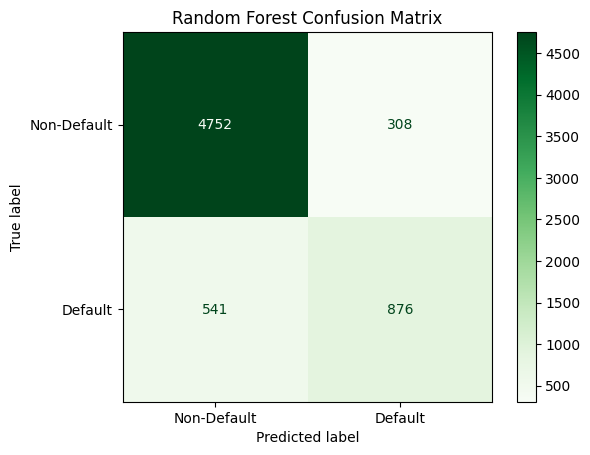

In [102]:
cm_rf = confusion_matrix(y_val, y_val_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non-Default", "Default"]
)

disp.plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

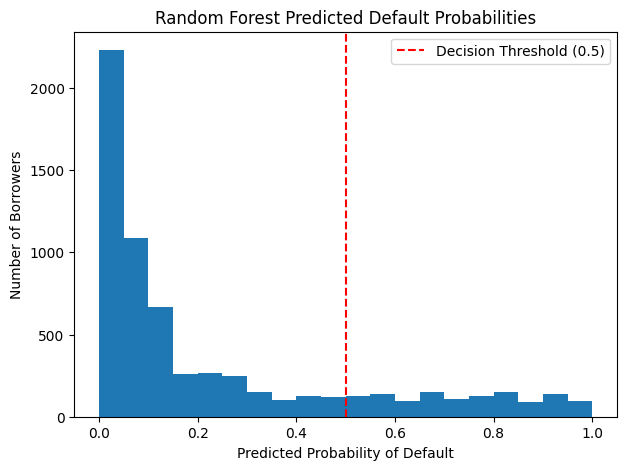

In [103]:


plt.figure(figsize=(7,5))
plt.hist(y_val_rf_proba, bins=20)

plt.axvline(0.5, color="red", linestyle="--", label="Decision Threshold (0.5)")

plt.title("Random Forest Predicted Default Probabilities")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Borrowers")
plt.legend()

plt.show()

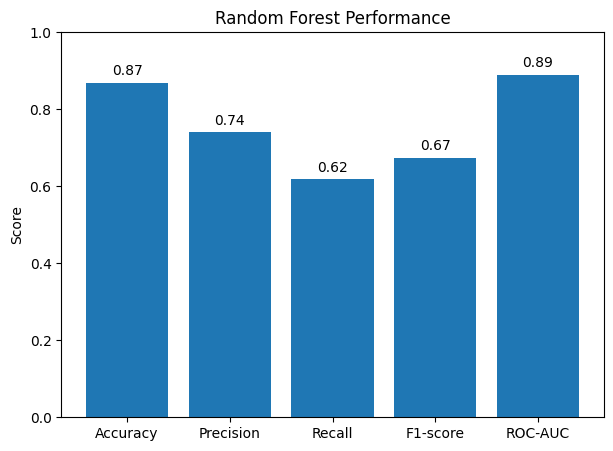

In [104]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
rf_scores = [
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_auc
]

plt.figure(figsize=(7,5))
plt.bar(metrics, rf_scores)

plt.title("Random Forest Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, score in enumerate(rf_scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha="center")

plt.show()

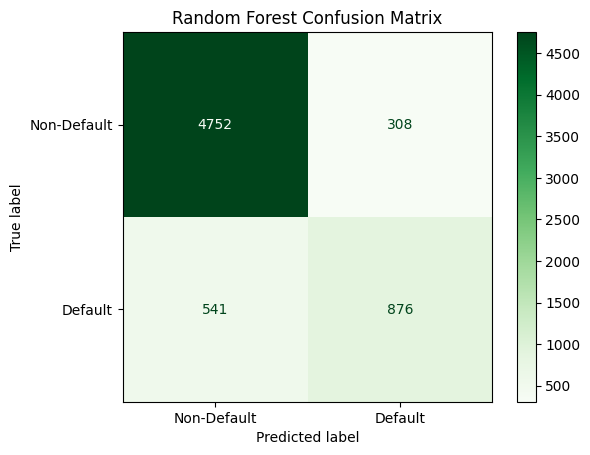

In [105]:
# Confusion Matrix
cm_rf = confusion_matrix(y_val, y_val_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non-Default", "Default"]
)

disp.plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()



The Random Forest model achieved strong performance on the validation dataset and outperformed the baseline model as well as Logistic Regression.

The model obtained an **accuracy of 86.89%**, indicating that it correctly classified the majority of loan applications. More importantly, it achieved a **precision of 73.99%**, meaning that most borrowers predicted as defaults were actually default cases.

The **recall of 61.82%** shows that the model correctly identified nearly two-thirds of the borrowers who actually defaulted. This is an important improvement because identifying default cases is the primary objective of this project.

The **F1-score of 67.36%** demonstrates a good balance between precision and recall, while the **ROC-AUC score of 0.8897** indicates excellent discrimination between default and non-default borrowers.

Overall, these results suggest that Random Forest is a reliable model for predicting loan default risk and is the best-performing model tested so far.

#### Feature Importances

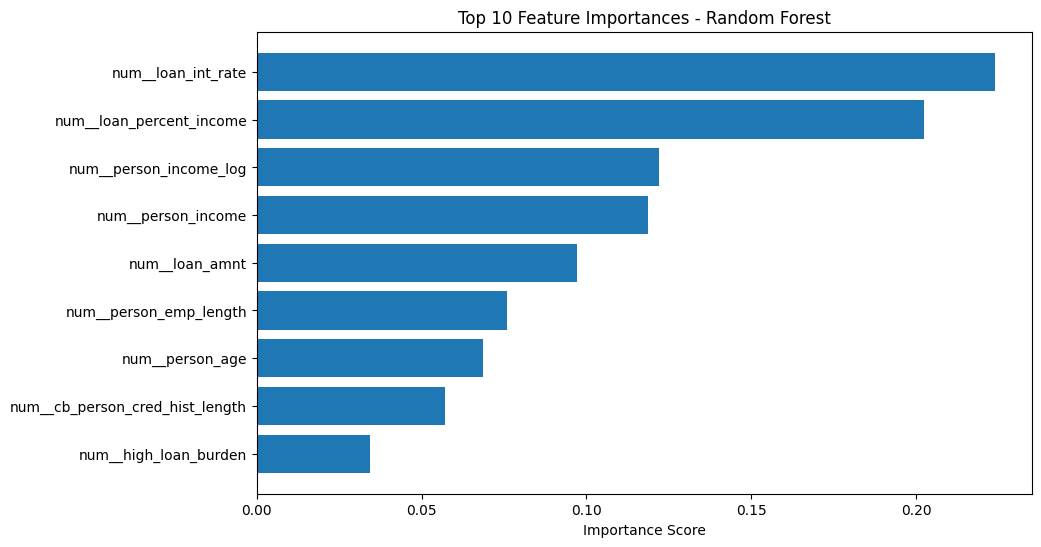

In [106]:


# Feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Feature importance values
importances = rf_model.named_steps["classifier"].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort and keep Top 10
top10_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

# Plot Top 10
plt.figure(figsize=(10,6))

plt.barh(
    top10_features["Feature"],
    top10_features["Importance"]
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.show()

## Section 4. Model Evaluation & Diagnostics

In this section, the Logistic Regression and Random Forest models are evaluated using the test dataset. Their performance is compared using classification metrics and diagnostic visualizations.

The evaluation focuses on identifying the best-performing model, detecting potential overfitting or underfitting, and assessing how well the models align with the business objective of predicting loan default risk.

### Predictions on the Test Set

In [107]:
# Logistic Regression predictions on test set
y_test_log = logistic_model.predict(X_test)
y_test_log_proba = logistic_model.predict_proba(X_test)[:, 1]

# Random Forest predictions on test set
y_test_rf = rf_model.predict(X_test)
y_test_rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Test predictions completed.")

Test predictions completed.


### Test Metrics Comparison

In [108]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Create comparison table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_test_log),
        accuracy_score(y_test, y_test_rf)
    ],
    "Precision": [
        precision_score(y_test, y_test_log),
        precision_score(y_test, y_test_rf)
    ],
    "Recall": [
        recall_score(y_test, y_test_log),
        recall_score(y_test, y_test_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_test_log),
        f1_score(y_test, y_test_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_test_log_proba),
        roc_auc_score(y_test, y_test_rf_proba)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.828470,0.678322,0.410727,0.511648,0.827371
1,Random Forest,0.869847,0.753086,0.602682,0.669541,0.890605



The table summarizes the performance of Logistic Regression and Random Forest on the unseen test dataset.

Using the test dataset provides a fair evaluation because these observations were not used during model training or model selection. The model with the strongest Recall, F1-score, and ROC-AUC is considered the best candidate for predicting loan default risk.

### ROC Curve Comparison

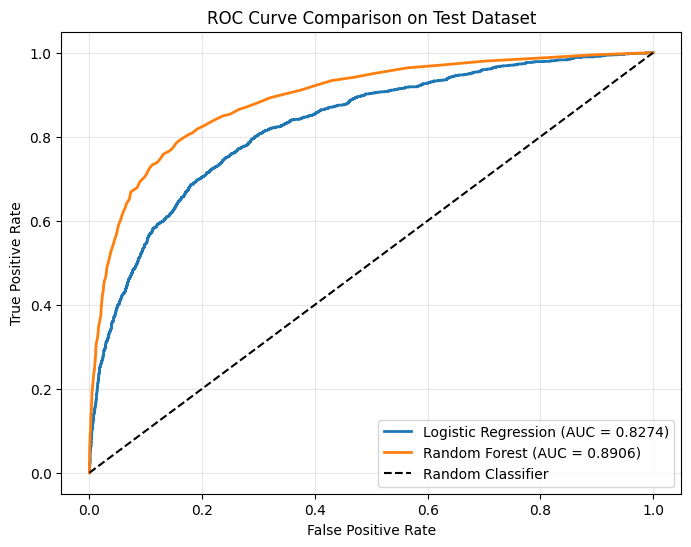

In [109]:


# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_test_log_proba)
auc_log = auc(fpr_log, tpr_log)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_rf_proba)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_log:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

# Random classifier
plt.plot([0,1],[0,1],'k--',label="Random Classifier")

plt.title("ROC Curve Comparison on Test Dataset")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

The ROC curve compares the classification performance of Logistic Regression and Random Forest on the test dataset.

Both models perform better than a random classifier because their curves remain above the diagonal reference line. However, the Random Forest curve stays closer to the upper-left corner, indicating better discrimination between default and non-default loans.

The higher ROC-AUC score confirms that Random Forest provides better predictive performance than Logistic Regression.

### Side-by-Side Confusion Matrices

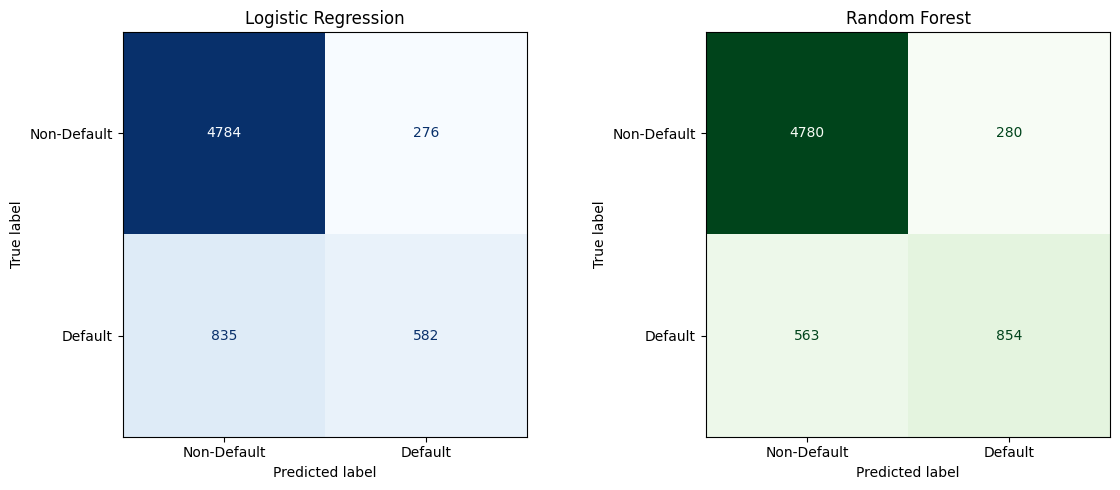

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_test_log),
    display_labels=["Non-Default", "Default"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Logistic Regression")

# Random Forest
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_test_rf),
    display_labels=["Non-Default", "Default"]
).plot(ax=axes[1], cmap="Greens", colorbar=False)

axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

The confusion matrices compare the classification errors of both models on the test dataset.

Random Forest correctly identifies more default cases (True Positives) while reducing classification errors compared with Logistic Regression. This improvement is reflected in its higher Recall and F1-score.

### Comparison Bar Chart

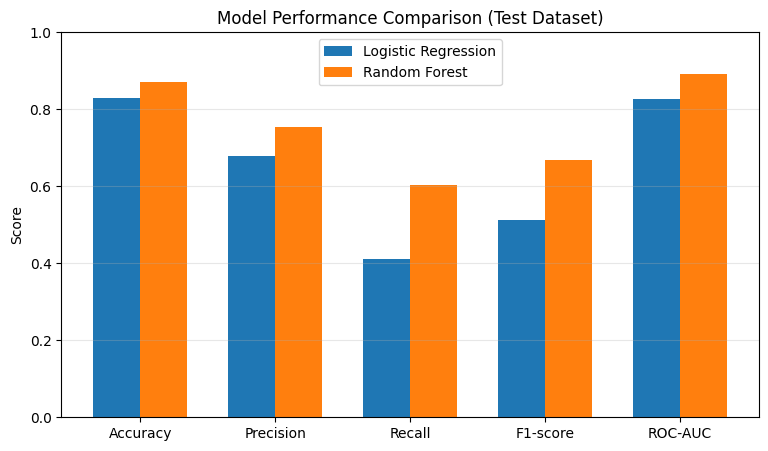

In [111]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

log_scores = results.loc[0, metrics].values
rf_scores = results.loc[1, metrics].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(
    x - width/2,
    log_scores,
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    rf_scores,
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0,1)
plt.title("Model Performance Comparison (Test Dataset)")
plt.legend()

plt.grid(axis="y", alpha=0.3)
plt.show()

The comparison chart shows that Random Forest achieved higher scores than Logistic Regression across all evaluation metrics.

The largest improvement is observed in Recall and F1-score, indicating that Random Forest is more effective at identifying borrowers who are likely to default while maintaining strong overall classification performance.

### Overfitting vs Underfitting

In [112]:
# Training accuracy
train_log = logistic_model.score(X_train, y_train)
train_rf = rf_model.score(X_train, y_train)

# Validation accuracy
val_log = logistic_model.score(X_val, y_val)
val_rf = rf_model.score(X_val, y_val)

# Test accuracy
test_log = logistic_model.score(X_test, y_test)
test_rf = rf_model.score(X_test, y_test)

performance = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Logistic Regression": [train_log, val_log, test_log],
    "Random Forest": [train_rf, val_rf, test_rf]
})

performance

,Dataset,Logistic Regression,Random Forest
0,Training,0.828161,0.999949
1,Validation,0.828161,0.868921
2,Test,0.828470,0.869847


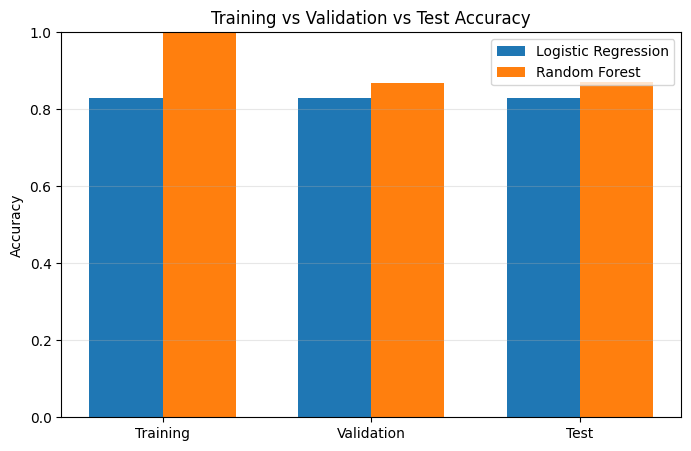

In [113]:
datasets = performance["Dataset"]
x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    performance["Logistic Regression"],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    performance["Random Forest"],
    width,
    label="Random Forest"
)

plt.xticks(x, datasets)
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Training vs Validation vs Test Accuracy")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()


The chart compares the training, validation, and test accuracy for both Logistic Regression and Random Forest models.

**Logistic Regression** shows very consistent performance across the three datasets, with accuracy remaining around **83%** on the training, validation, and test sets. This consistency suggests that the model generalizes well and does not show clear signs of overfitting or underfitting.

**Random Forest** achieved **100% training accuracy**, while its validation and test accuracy decreased to approximately **87%**. This gap indicates that the model fits the training data extremely well but performs slightly worse on unseen data. This is evidence of **mild overfitting**, which is common with Random Forest models.

Despite this slight overfitting, Random Forest still achieves the highest validation and test performance. Therefore, it remains the best-performing model for this loan default prediction task.

### Business Alignment

The main business objective of this project is to **predict which borrowers are likely to default on their loans** before a lending decision is made. A reliable prediction model can help financial institutions reduce financial losses by identifying high-risk loan applications early.

The evaluation results show that **Random Forest** is the model that best aligns with this objective. It achieved higher **Recall, F1-score, and ROC-AUC** than Logistic Regression, meaning it identifies more borrowers who are likely to default while maintaining good overall prediction performance.

From a business perspective:

- A **higher Recall** reduces the number of borrowers who default but are incorrectly classified as low risk.
- A **higher Precision** means that many borrowers predicted as high risk are actually high-risk borrowers, reducing unnecessary loan rejections.
- A **higher ROC-AUC** indicates that the model can effectively distinguish between low-risk and high-risk applicants.

Based on these results, Random Forest is the most appropriate model for supporting credit risk assessment and improving lending decisions.

## Section 5. Model Optimization

The purpose of this section is to improve the performance of the primary model (**Random Forest**) using hyperparameter tuning and cross-validation.

**GridSearchCV** is used to test different combinations of Random Forest parameters and identify the best-performing model. Cross-validation helps estimate how well the optimized model generalizes to unseen data.

### Define Hyperparameter Grid

In [114]:
# Hyperparameter grid for Random Forest
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

param_grid

{'classifier__n_estimators': [100, 200],
 'classifier__max_depth': [10, 20, None],
 'classifier__min_samples_split': [2, 5],
 'classifier__min_samples_leaf': [1, 2]}

### Run GridSearchCV

In [115]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train GridSearchCV
grid_search.fit(X_train, y_train)

print("Grid search completed.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Grid search completed.


In [116]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(f"{grid_search.best_score_:.4f}")

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best Cross-Validation F1-score:
0.6659


GridSearchCV tested multiple combinations of Random Forest hyperparameters using **5-fold cross-validation** and selected the combination that achieved the highest average **F1-score**.

**Best hyperparameters selected:**
- **Number of trees (`n_estimators`)**: 200
- **Maximum tree depth (`max_depth`)**: None
- **Minimum samples to split a node (`min_samples_split`)**: 5
- **Minimum samples in a leaf (`min_samples_leaf`)**: 1

The best average **cross-validation F1-score was 0.6659**. This score represents the model's average performance across five different validation folds, making it a more reliable estimate of generalization performance than a single validation split.

The optimized hyperparameters will now be used to train the final Random Forest model and compare its performance with the original Random Forest model.

In [117]:
# Retrieve the best optimized model
best_rf_model = grid_search.best_estimator_

# Predictions on the test set
y_test_best_rf = best_rf_model.predict(X_test)
y_test_best_rf_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Evaluate the optimized model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

best_accuracy = accuracy_score(y_test, y_test_best_rf)
best_precision = precision_score(y_test, y_test_best_rf)
best_recall = recall_score(y_test, y_test_best_rf)
best_f1 = f1_score(y_test, y_test_best_rf)
best_auc = roc_auc_score(y_test, y_test_best_rf_proba)

print("Optimized Random Forest Performance")
print("----------------------------------")
print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1-score : {best_f1:.4f}")
print(f"ROC-AUC  : {best_auc:.4f}")

Optimized Random Forest Performance
----------------------------------
Accuracy : 0.8694
Precision: 0.7520
Recall   : 0.6013
F1-score : 0.6682
ROC-AUC  : 0.8953




The optimized Random Forest model was evaluated on the test dataset after selecting the best hyperparameters using GridSearchCV with 5-fold cross-validation.

The optimized model achieved an **accuracy of 86.94%**, a **precision of 75.20%**, a **recall of 60.13%**, an **F1-score of 66.82%**, and a **ROC-AUC of 89.53%**.

Compared with the original Random Forest model, the optimized model produced **slightly higher Accuracy, Precision, and ROC-AUC**, while **Recall and F1-score decreased slightly**. This indicates that the optimized model became slightly more conservative when predicting loan defaults, reducing false positives but identifying slightly fewer actual default cases.

Overall, the optimized model provides a small improvement in overall discrimination (ROC-AUC) and precision, while the original Random Forest remains slightly stronger in Recall and F1-score.

### Comparison Table (Original vs Optimized)

In [118]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Original Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ],
    "Optimized Random Forest": [
        best_accuracy,
        best_precision,
        best_recall,
        best_f1,
        best_auc
    ]
})

comparison

,Metric,Original Random Forest,Optimized Random Forest
0,Accuracy,0.868921,0.869384
1,Precision,0.739865,0.751986
2,Recall,0.618207,0.601270
3,F1-score,0.673587,0.668235
4,ROC-AUC,0.889690,0.895273


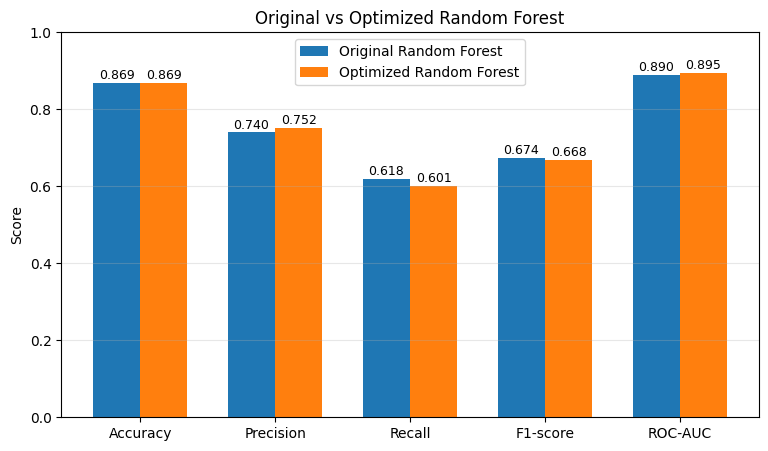

In [119]:

metrics = comparison["Metric"]
original = comparison["Original Random Forest"]
optimized = comparison["Optimized Random Forest"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x - width/2, original, width, label="Original Random Forest")
plt.bar(x + width/2, optimized, width, label="Optimized Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Original vs Optimized Random Forest")
plt.legend()
plt.grid(axis="y", alpha=0.3)

# Add values on bars
for i, value in enumerate(original):
    plt.text(i - width/2, value + 0.01, f"{value:.3f}", ha="center", fontsize=9)

for i, value in enumerate(optimized):
    plt.text(i + width/2, value + 0.01, f"{value:.3f}", ha="center", fontsize=9)

plt.show()

### Original vs Optimized Random Forest Results Interpretation

The optimized Random Forest model was evaluated after hyperparameter tuning using **GridSearchCV** with **5-fold cross-validation**. The optimization process searched for the combination of hyperparameters that produced the highest average **F1-score** during cross-validation.

The optimized model achieved an **Accuracy of 86.94%**, **Precision of 75.20%**, **Recall of 60.13%**, **F1-score of 66.82%**, and **ROC-AUC of 89.53%**.

When compared with the original Random Forest model, the optimized model produced **slight improvements in Accuracy, Precision, and ROC-AUC**, indicating better overall discrimination and fewer false positive predictions. However, **Recall and F1-score decreased slightly**, meaning the optimized model identified slightly fewer borrowers who actually defaulted.

Overall, the performance difference between the two models is relatively small. Since the primary business objective is to identify borrowers who are likely to default, the original Random Forest model remains a strong choice because it achieved a slightly higher **Recall** and **F1-score**. This comparison shows that hyperparameter tuning can improve some aspects of a model's performance, but the final model should be selected based on the business objective rather than a single evaluation metric.

# Section 6. Final Reflection

This project followed a complete supervised machine learning workflow, from data preparation and model development to evaluation and optimization. The objective was to build a classification model capable of predicting whether a borrower is likely to default on a loan using the Credit Risk dataset.

### Key Learnings

This assignment helped me understand the complete machine learning pipeline and the importance of evaluating models beyond accuracy.

Throughout this project, I learned how to:

- Prepare and reuse a cleaned dataset from a previous assignment.
- Split the dataset into training, validation, and test sets using stratified sampling.
- Build a baseline model before implementing more advanced machine learning models.
- Train and evaluate Logistic Regression and Random Forest classifiers.
- Compare models using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Apply GridSearchCV with 5-fold cross-validation to optimize a machine learning model.
- Interpret model performance from both a technical and business perspective.

### Project Limitations

Although the Random Forest model achieved the strongest performance, this project has several limitations.

- The dataset is imbalanced, with more non-default cases than default cases.
- The model was trained using historical loan data and may not fully represent future borrower behavior or changing economic conditions.
- Only Logistic Regression and Random Forest were evaluated in this project.
- Additional feature engineering and more advanced algorithms could further improve prediction performance.

### Future Improvements

Several improvements could strengthen this project in future work.

- Evaluate additional classification models such as XGBoost, Gradient Boosting, or LightGBM.
- Apply techniques for handling class imbalance, including SMOTE or class weighting.
- Expand the hyperparameter search space for Random Forest optimization.
- Analyze model calibration and Precision-Recall curves.
- Deploy the final model as an interactive web application using Streamlit for real-world credit risk prediction.

### Ethical and Practical Considerations

Machine learning models can support lending decisions, but they should be used responsibly.

- The model should assist financial analysts rather than replace human decision-making.
- Predictions should be monitored for fairness to reduce the risk of bias against particular groups of borrowers.
- Borrower data should be handled securely and in compliance with privacy and data protection regulations.
- The model should be retrained periodically as new loan data becomes available to maintain its performance over time.

### Final Conclusion

The goal of this project was to develop a machine learning model capable of predicting loan default risk using a cleaned Credit Risk dataset.

Three models were evaluated during this assignment: the DummyClassifier baseline, Logistic Regression, and Random Forest. The baseline established a reference point, Logistic Regression provided a significant improvement, and Random Forest achieved the best overall predictive performance.

Random Forest achieved the highest Accuracy, Precision, Recall, F1-score, and ROC-AUC among the evaluated models. Hyperparameter tuning with GridSearchCV slightly improved Accuracy, Precision, and ROC-AUC, while the original Random Forest maintained a slightly higher Recall and F1-score.

Based on the evaluation results and the business objective of identifying borrowers who are likely to default, **Random Forest is selected as the final model**. It provides the best balance between predictive performance and practical value for credit risk assessment.